<a href="https://colab.research.google.com/github/Bright629-design/Maps-and-mnist-training/blob/main/Australia_Regions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Loaded regions: ['New South Wales', 'Victoria', 'Queensland', 'South Australia', 'Western Australia', 'Tasmania', 'Northern Territory', 'Australian Capital Territory']
✅ Merged into regions: ['NSW/VIC', 'NT', 'QLD', 'SA', 'WA']

🎨 Color assignments:
   WA            →  teal  (#3DB89A)
   NT            →  purple  (#7B6FD4)
   SA            →  amber  (#E8A020)
   QLD           →  teal  (#3DB89A)
   NSW/VIC       →  purple  (#7B6FD4)


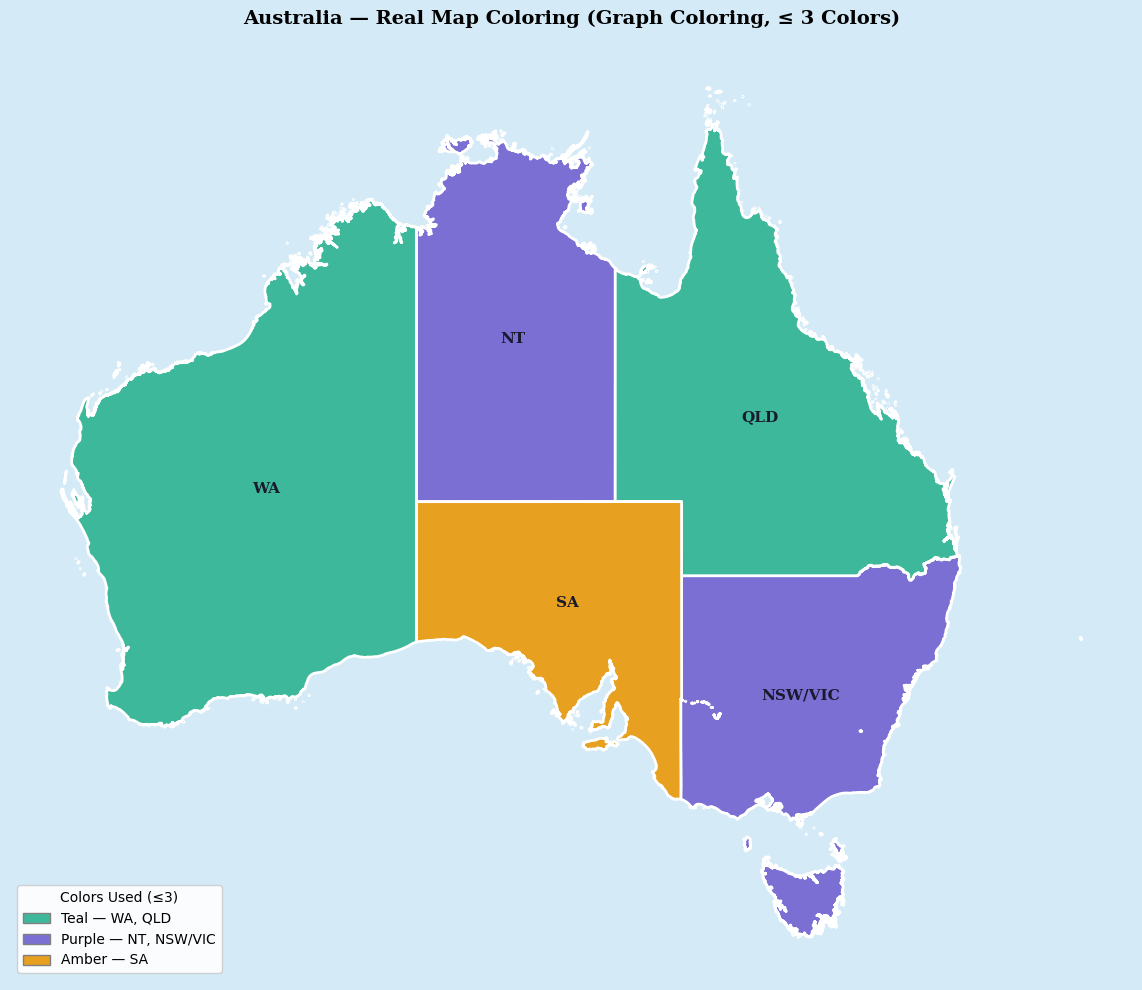


🗺️  Saved as 'australia_real_map.png'


In [ ]:
# ============================================================
# Australia REAL Map Coloring — Max 3 Colors, 5 Regions
# Uses real GeoJSON boundaries + graph coloring algorithm
# Run in Google Colab
# ============================================================

# Install required libraries
!pip install geopandas matplotlib requests --quiet

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests
import json

# ---- 1. Download real Australia state boundaries (GeoJSON) ----
url = "https://raw.githubusercontent.com/rowanhogan/australian-states/master/states.geojson"
response = requests.get(url)
gdf = gpd.read_file(response.text)

print("✅ Loaded regions:", list(gdf['STATE_NAME']))

# ---- 2. Group into 5 regions --------------------------------
#  (Tasmania, ACT are small — merge with nearest for simplicity)
region_map = {
    "Western Australia":   "WA",
    "Northern Territory":  "NT",
    "South Australia":     "SA",
    "Queensland":          "QLD",
    "New South Wales":     "NSW/VIC",
    "Victoria":            "NSW/VIC",
    "Australian Capital Territory": "NSW/VIC",
    "Tasmania":            "NSW/VIC",
}

gdf["region"] = gdf["STATE_NAME"].map(region_map)
gdf_merged = gdf.dissolve(by="region").reset_index()

print("✅ Merged into regions:", list(gdf_merged["region"]))

# ---- 3. Graph coloring (greedy, max 3 colors) ---------------
adjacency = {
    "WA":      ["NT", "SA"],
    "NT":      ["WA", "SA", "QLD"],
    "SA":      ["WA", "NT", "QLD", "NSW/VIC"],
    "QLD":     ["NT", "SA", "NSW/VIC"],
    "NSW/VIC": ["SA", "QLD"],
}

color_names  = ["teal", "purple", "amber"]
hex_colors   = {
    "teal":   "#3DB89A",
    "purple": "#7B6FD4",
    "amber":  "#E8A020",
}
color_map = {}

for region in adjacency:
    used = {color_map[nb] for nb in adjacency[region] if nb in color_map}
    for c in color_names:
        if c not in used:
            color_map[region] = c
            break

print("\n🎨 Color assignments:")
for r, c in color_map.items():
    print(f"   {r:12s}  →  {c}  ({hex_colors[c]})")

# ---- 4. Plot with real geography ----------------------------
gdf_merged["color"] = gdf_merged["region"].map(
    lambda r: hex_colors[color_map.get(r, "teal")]
)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor("#D4EAF7")
ax.set_facecolor("#D4EAF7")

gdf_merged.plot(
    ax=ax,
    color=gdf_merged["color"],
    edgecolor="white",
    linewidth=2.0,
)

# Labels at region centroids
for _, row in gdf_merged.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        row["region"],
        xy=(centroid.x, centroid.y),
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        color='#1a1a2e',
        fontfamily='serif'
    )

# Legend
legend_patches = [
    mpatches.Patch(facecolor=hex_colors[c], edgecolor='gray',
                   label=f"{c.capitalize()} — {', '.join(r for r,v in color_map.items() if v==c)}")
    for c in color_names if c in color_map.values()
]
ax.legend(handles=legend_patches, loc='lower left',
          fontsize=10, title="Colors Used (≤3)",
          title_fontsize=10, framealpha=0.9)

ax.set_title(
    "Australia — Real Map Coloring (Graph Coloring, ≤ 3 Colors)",
    fontsize=14, fontweight='bold', pad=15, fontfamily='serif'
)
ax.axis('off')
plt.tight_layout()
plt.savefig("australia_real_map.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n🗺️  Saved as 'australia_real_map.png'")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data Shape: (60000, 28, 28)
Training labels Shape: (60000,)
Test data Shape: (10000, 28, 28)
Test labels Shape: (10000,)
Number of training samples: 60000
Number of test samples: 10000


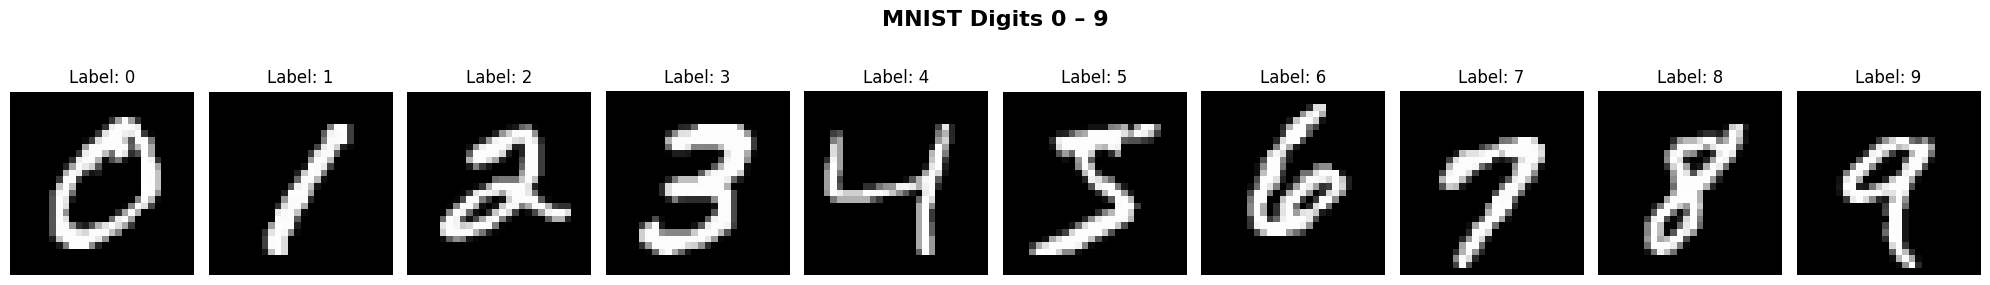

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize data
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Print dataset info
print("Training data Shape:",  x_train.shape)
print("Training labels Shape:", y_train.shape)
print("Test data Shape:",       x_test.shape)
print("Test labels Shape:",     y_test.shape)
print("Number of training samples:", len(x_train))
print("Number of test samples:",     len(x_test))

# ── Find one example image for each digit 0–9 ──────────────────────────
digit_images = {}

for i, label in enumerate(y_train):           # loop through every training sample
    label = int(label)
    if label not in digit_images:             # only store the FIRST occurrence
        digit_images[label] = x_train[i]
    if len(digit_images) == 10:               # stop once we have all 10 digits
        break

# ── Display all 10 digits in a single row ──────────────────────────────
fig, axes = plt.subplots(1, 10, figsize=(20, 3))   # 1 row, 10 columns
fig.suptitle("MNIST Digits 0 – 9", fontsize=16, fontweight='bold', y=1.02)

for digit in range(10):                       # digit = 0, 1, 2 ... 9
    ax = axes[digit]
    ax.imshow(digit_images[digit], cmap='gray')
    ax.set_title(f"Label: {digit}", fontsize=12)
    ax.axis('off')                            # hide axis ticks

plt.tight_layout()
plt.show()